# PHQ-9 Mental Health Dataset Analysis
## Comprehensive Analysis of Depression Screening Data for College Students

This notebook performs an in-depth analysis of the PHQ-9 (Patient Health Questionnaire-9) dataset, examining depression symptoms, severity levels, and their relationships with demographic factors and life pressures.

## Section 1: Load and Explore the Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('PHQ-9_Dataset_5th Edition.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("Column Names and Data Types:")
print(df.dtypes)
print("\n" + "="*80)
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*80)
print("Dataset Info:")
print(df.info())


Dataset Shape: (682, 16)

Column Names and Data Types:
Age                                                                                                                                                                         int64
Gender                                                                                                                                                                        str
Little interest or pleasure in doing things                                                                                                                                   str
  Feeling down, depressed, or hopeless                                                                                                                                        str
  Trouble falling or staying asleep, or sleeping too much                                                                                                                     str
  Feeling tired or having little energy                

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80)

# Get statistical summary
print("Statistical Summary:")
print(df.describe())
print("\n" + "="*80)

# Check data types and memory usage
print("Memory Usage:")
print(df.memory_usage(deep=True))


Missing Values:
Age                                                                                                                                                                         0
Gender                                                                                                                                                                      0
Little interest or pleasure in doing things                                                                                                                                 0
  Feeling down, depressed, or hopeless                                                                                                                                      0
  Trouble falling or staying asleep, or sleeping too much                                                                                                                   0
  Feeling tired or having little energy                                                                           

## Section 2: Data Preprocessing and Cleaning

In [4]:
# Create a copy for preprocessing
df_processed = df.copy()

# Map frequency responses to numerical values
frequency_mapping = {
    'Not at all': 0,
    'Several days': 1,
    'More than half the days': 2,
    'Nearly every day': 3
}

# Get PHQ-9 symptom column names
symptom_columns = [col for col in df.columns if col not in 
                   ['Age', 'Gender', 'PHQ_Total', 'PHQ_Severity', 'Sleep Quality', 'Study Pressure', 'Financial Pressure']]

print("Symptom Columns Identified:")
for i, col in enumerate(symptom_columns, 1):
    print(f"{i}. {col}")
print(f"\nTotal Symptom Questions: {len(symptom_columns)}")

# Apply frequency mapping to all symptom columns
for col in symptom_columns:
    df_processed[col] = df_processed[col].map(frequency_mapping)

print("\n" + "="*80)
print("Data after numerical encoding:")
print(df_processed.head())


Symptom Columns Identified:
1. Little interest or pleasure in doing things 
2.   Feeling down, depressed, or hopeless  
3.   Trouble falling or staying asleep, or sleeping too much  
4.   Feeling tired or having little energy  
5.   Poor appetite or overeating  
6. Feeling bad about yourself—or that you are a failure or have let yourself or your family down  
7. Trouble concentrating on things, such as reading the newspaper or watching television  
8. Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual  
9. Thoughts that you would be better off dead or of hurting yourself in some way  

Total Symptom Questions: 9

Data after numerical encoding:
   Age  Gender  Little interest or pleasure in doing things   \
0   22    Male                                             2   
1   25    Male                                             0   
2   22  Female                          

In [5]:
# Encode categorical variables
# Gender encoding
df_processed['Gender'] = df_processed['Gender'].map({'Male': 0, 'Female': 1})

# Severity levels encoding (ordinal)
severity_mapping = {
    'Minimal': 0,
    'Mild': 1,
    'Moderate': 2,
    'Moderately severe': 3,
    'Severe': 4
}
df_processed['PHQ_Severity'] = df_processed['PHQ_Severity'].map(severity_mapping)

# Sleep Quality encoding
sleep_mapping = {
    'Good': 0,
    'Average': 1,
    'Bad': 2,
    'Worst': 3
}
df_processed['Sleep Quality'] = df_processed['Sleep Quality'].map(sleep_mapping)

# Study Pressure encoding
df_processed['Study Pressure'] = df_processed['Study Pressure'].map(sleep_mapping)

# Financial Pressure encoding
df_processed['Financial Pressure'] = df_processed['Financial Pressure'].map(sleep_mapping)

print("Data after categorical encoding:")
print(df_processed.head())
print("\n" + "="*80)
print("Data types after encoding:")
print(df_processed.dtypes)


Data after categorical encoding:
   Age  Gender  Little interest or pleasure in doing things   \
0   22       0                                             2   
1   25       0                                             0   
2   22       1                                             0   
3   18       1                                             3   
4   24       0                                             0   

     Feeling down, depressed, or hopeless    \
0                                         0   
1                                         0   
2                                         0   
3                                         3   
4                                         0   

     Trouble falling or staying asleep, or sleeping too much    \
0                                                  0             
1                                                  3             
2                                                  0             
3                                  

## Section 3: Exploratory Data Analysis (EDA)

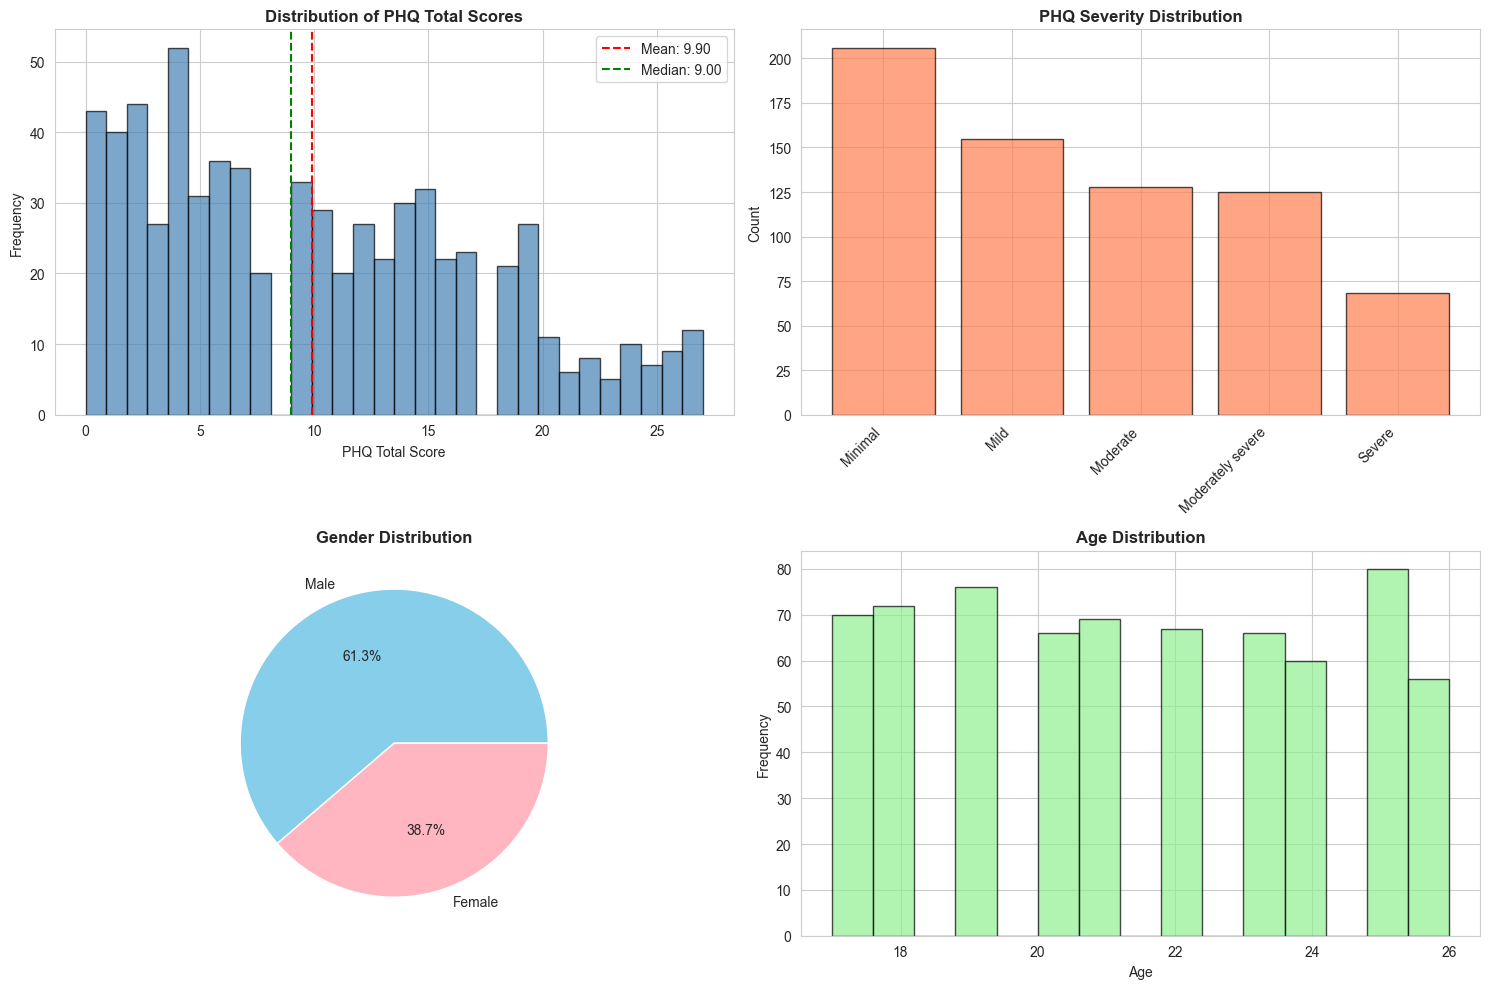

Key Statistics:
Average Age: 21.39
Average PHQ Total Score: 9.90
Average PHQ Score Std Dev: 7.22
Min PHQ Score: 0
Max PHQ Score: 27


In [6]:
# Distribution of PHQ Total Scores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram of PHQ Total Scores
axes[0, 0].hist(df_processed['PHQ_Total'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of PHQ Total Scores', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('PHQ Total Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df_processed['PHQ_Total'].mean(), color='red', linestyle='--', label=f'Mean: {df_processed["PHQ_Total"].mean():.2f}')
axes[0, 0].axvline(df_processed['PHQ_Total'].median(), color='green', linestyle='--', label=f'Median: {df_processed["PHQ_Total"].median():.2f}')
axes[0, 0].legend()

# Count plot of PHQ Severity
severity_counts = df['PHQ_Severity'].value_counts()
severity_order = ['Minimal', 'Mild', 'Moderate', 'Moderately severe', 'Severe']
severity_counts = severity_counts.reindex(severity_order)
axes[0, 1].bar(range(len(severity_counts)), severity_counts.values, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xticks(range(len(severity_counts)))
axes[0, 1].set_xticklabels(severity_counts.index, rotation=45, ha='right')
axes[0, 1].set_title('PHQ Severity Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Count')

# Gender Distribution
gender_counts = df['Gender'].value_counts()
axes[1, 0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightpink'])
axes[1, 0].set_title('Gender Distribution', fontsize=12, fontweight='bold')

# Age Distribution
axes[1, 1].hist(df_processed['Age'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Age')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Key Statistics:")
print(f"Average Age: {df_processed['Age'].mean():.2f}")
print(f"Average PHQ Total Score: {df_processed['PHQ_Total'].mean():.2f}")
print(f"Average PHQ Score Std Dev: {df_processed['PHQ_Total'].std():.2f}")
print(f"Min PHQ Score: {df_processed['PHQ_Total'].min()}")
print(f"Max PHQ Score: {df_processed['PHQ_Total'].max()}")


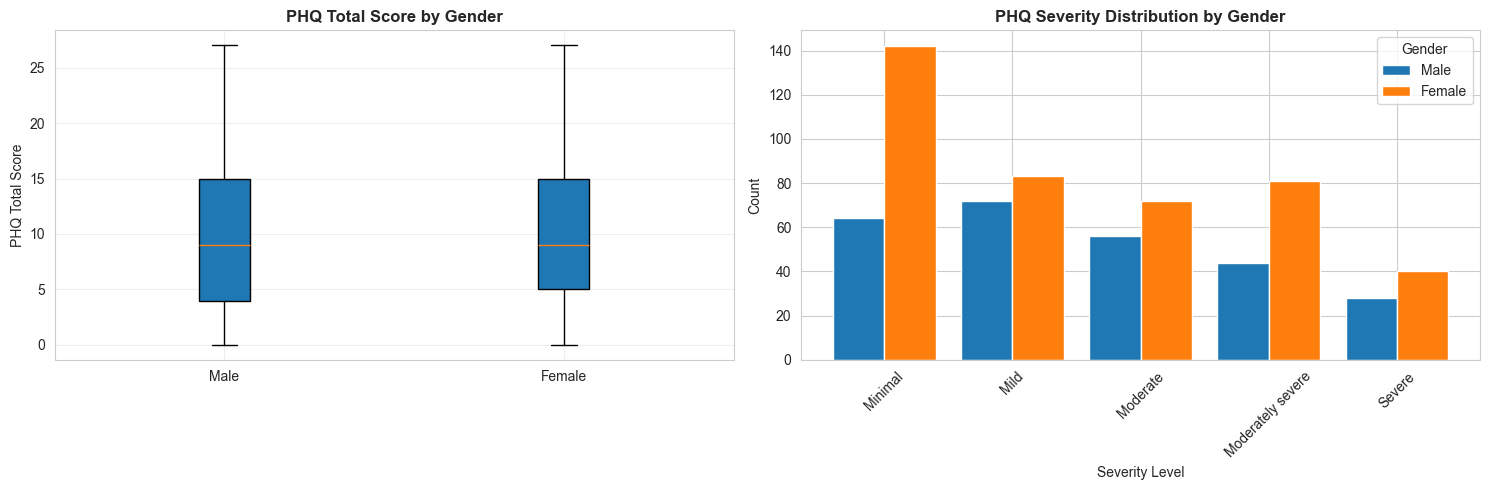

PHQ Total Score Statistics by Gender:
        count       mean       std  min  25%  50%   75%   max
Gender                                                       
0       418.0   9.748804  7.355095  0.0  4.0  9.0  15.0  27.0
1       264.0  10.147727  7.010378  0.0  5.0  9.0  15.0  27.0


In [7]:
# Analyze Mental Health by Gender
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PHQ Score by Gender
gender_data = [df_processed[df_processed['Gender'] == 0]['PHQ_Total'], 
               df_processed[df_processed['Gender'] == 1]['PHQ_Total']]
axes[0].boxplot(gender_data, labels=['Male', 'Female'], patch_artist=True)
axes[0].set_title('PHQ Total Score by Gender', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PHQ Total Score')
axes[0].grid(True, alpha=0.3)

# Severity by Gender
gender_severity = df.groupby('Gender')['PHQ_Severity'].value_counts().unstack(fill_value=0)
gender_severity = gender_severity.reindex(severity_order, axis=1, fill_value=0)
gender_severity.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('PHQ Severity Distribution by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Severity Level')
axes[1].legend(title='Gender', labels=['Male', 'Female'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistical summary by gender
print("PHQ Total Score Statistics by Gender:")
print(df_processed.groupby('Gender')['PHQ_Total'].describe())


## Section 4: Statistical Analysis of Mental Health Indicators

Correlation of Individual Symptoms with Total PHQ Score:
  Feeling tired or having little energy                                                                                                                                     0.752063
  Poor appetite or overeating                                                                                                                                               0.738067
  Trouble falling or staying asleep, or sleeping too much                                                                                                                   0.724365
Thoughts that you would be better off dead or of hurting yourself in some way                                                                                               0.717083
Moving or speaking so slowly that other people could have noticed? Or the opposite—being so fidgety or restless that you have been moving around a lot more than usual      0.716423
Feeling bad about yourself—or that you

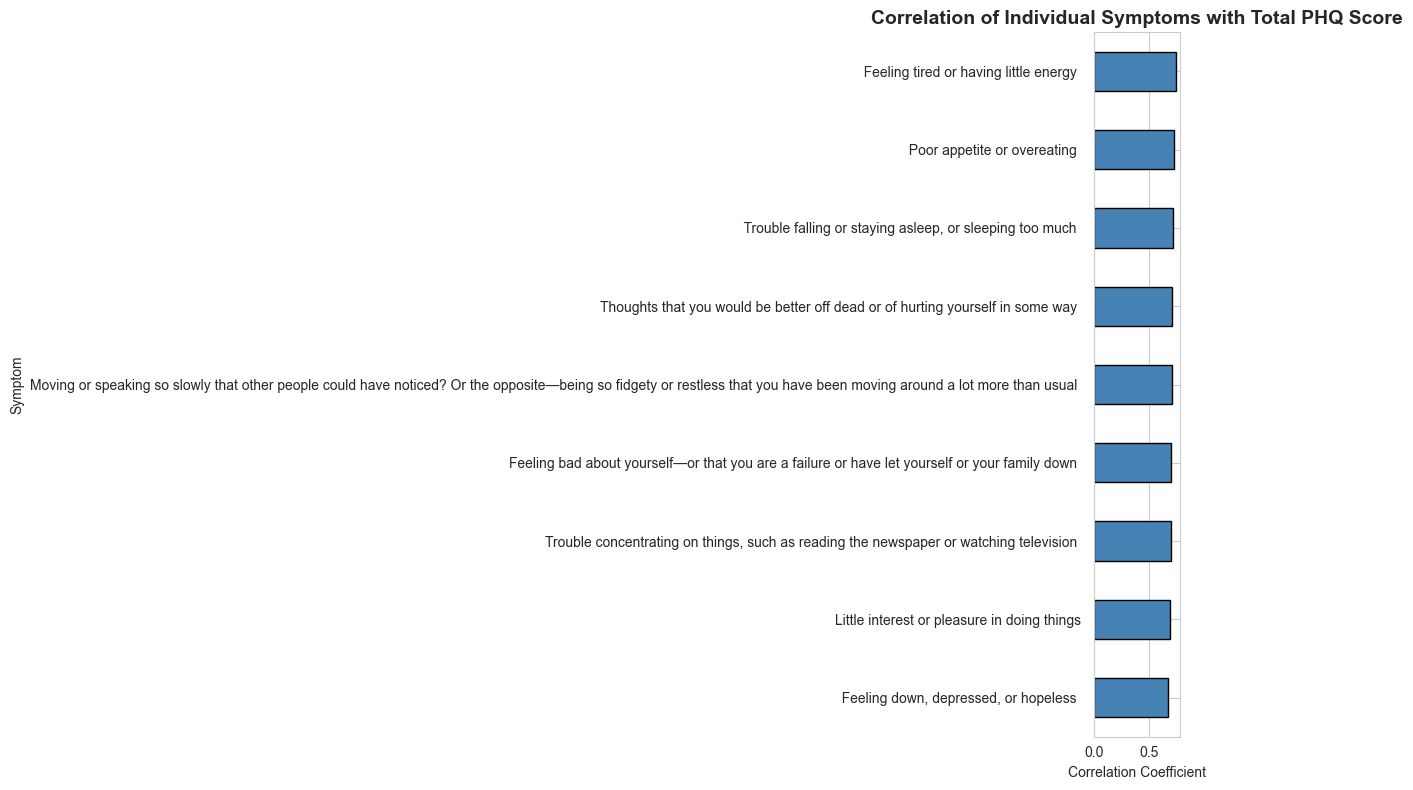


Average Symptom Frequency by PHQ Severity Level:
                   Little interest or pleasure in doing things   \
Minimal                                                0.179612   
Mild                                                   0.703226   
Moderate                                               1.429688   
Moderately Severe                                      1.728000   
Severe                                                 2.544118   

                     Feeling down, depressed, or hopeless    \
Minimal                                            0.203883   
Mild                                               0.806452   
Moderate                                           1.265625   
Moderately Severe                                  1.608000   
Severe                                             2.617647   

                     Trouble falling or staying asleep, or sleeping too much    \
Minimal                                                     0.189320             
Mild

In [8]:
# Correlation between individual symptoms and total PHQ score
print("Correlation of Individual Symptoms with Total PHQ Score:")
print("="*80)
symptom_correlations = df_processed[symptom_columns + ['PHQ_Total']].corr()['PHQ_Total'].drop('PHQ_Total').sort_values(ascending=False)
print(symptom_correlations)

# Visualize symptom correlations
fig, ax = plt.subplots(figsize=(12, 8))
symptom_correlations.sort_values().plot(kind='barh', color='steelblue', edgecolor='black', ax=ax)
ax.set_title('Correlation of Individual Symptoms with Total PHQ Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Symptom')
plt.tight_layout()
plt.show()

# Average symptom frequency by severity level
print("\n" + "="*80)
print("Average Symptom Frequency by PHQ Severity Level:")
print("="*80)
severity_symptom_means = df_processed.groupby('PHQ_Severity')[symptom_columns].mean()
severity_symptom_means.index = ['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']
print(severity_symptom_means)


In [9]:
# Hypothesis Testing - Compare mental health by life pressures
from scipy import stats

print("Statistical Comparison of PHQ Scores by Life Pressures:")
print("="*80)

# Compare by Sleep Quality
sleep_groups = [df_processed[df_processed['Sleep Quality'] == i]['PHQ_Total'].values 
                for i in range(4)]
f_stat_sleep, p_val_sleep = stats.f_oneway(*sleep_groups)
print(f"Sleep Quality - F-statistic: {f_stat_sleep:.4f}, p-value: {p_val_sleep:.4e}")

# Compare by Study Pressure
study_groups = [df_processed[df_processed['Study Pressure'] == i]['PHQ_Total'].values 
                for i in range(4)]
f_stat_study, p_val_study = stats.f_oneway(*study_groups)
print(f"Study Pressure - F-statistic: {f_stat_study:.4f}, p-value: {p_val_study:.4e}")

# Compare by Financial Pressure
fin_groups = [df_processed[df_processed['Financial Pressure'] == i]['PHQ_Total'].values 
              for i in range(4)]
f_stat_fin, p_val_fin = stats.f_oneway(*fin_groups)
print(f"Financial Pressure - F-statistic: {f_stat_fin:.4f}, p-value: {p_val_fin:.4e}")

print("\n" + "="*80)
print("Interpretation: p-value < 0.05 indicates significant differences in PHQ scores")


Statistical Comparison of PHQ Scores by Life Pressures:
Sleep Quality - F-statistic: 78.8477, p-value: 9.2227e-44
Study Pressure - F-statistic: 98.0766, p-value: 9.8436e-53
Financial Pressure - F-statistic: 47.6853, p-value: 5.7030e-28

Interpretation: p-value < 0.05 indicates significant differences in PHQ scores


## Section 5: Correlation and Relationship Analysis

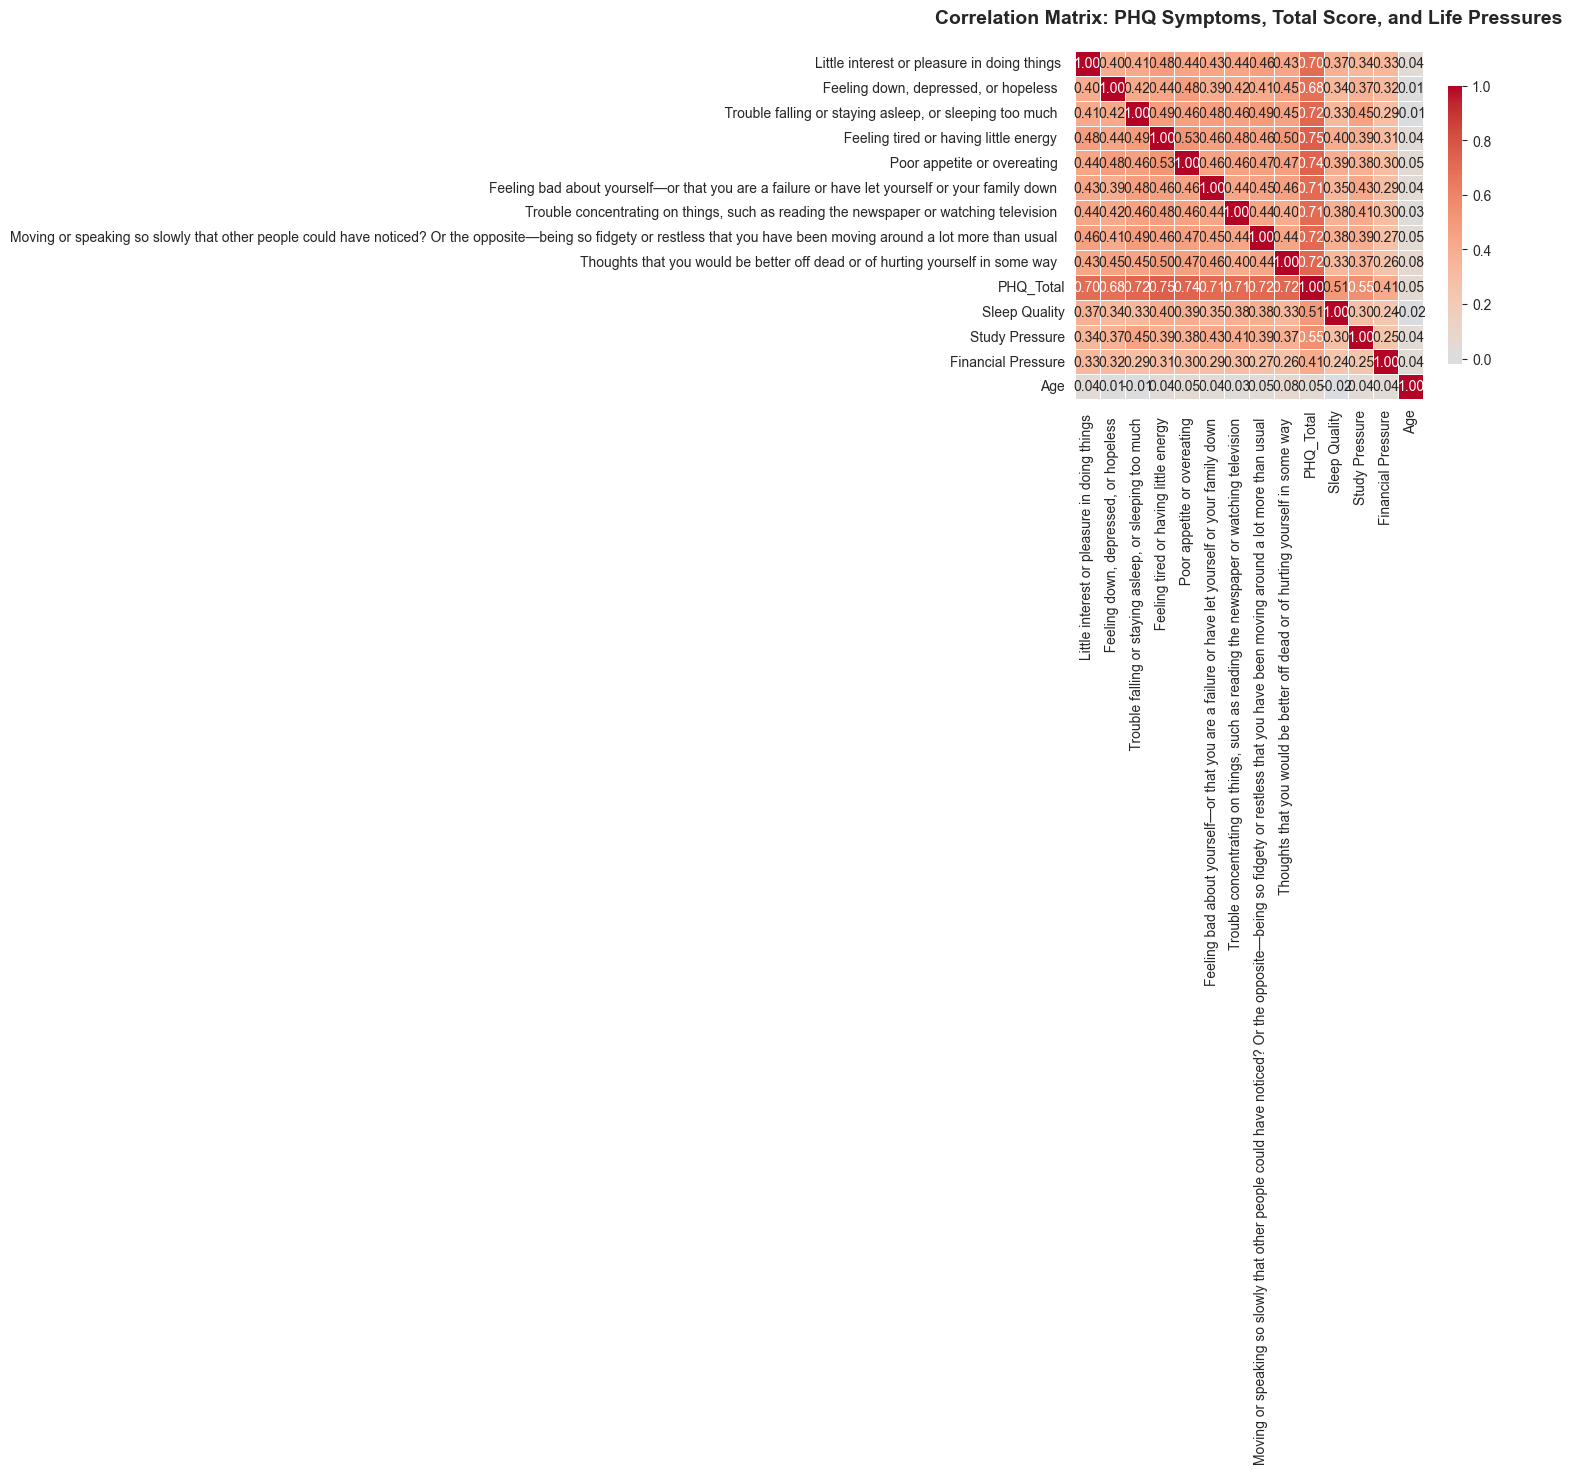

Correlation Matrix Summary Created


In [10]:
# Create correlation matrix for all numerical variables
correlation_vars = symptom_columns + ['PHQ_Total', 'Sleep Quality', 'Study Pressure', 'Financial Pressure', 'Age']
correlation_matrix = df_processed[correlation_vars].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix: PHQ Symptoms, Total Score, and Life Pressures', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Correlation Matrix Summary Created")


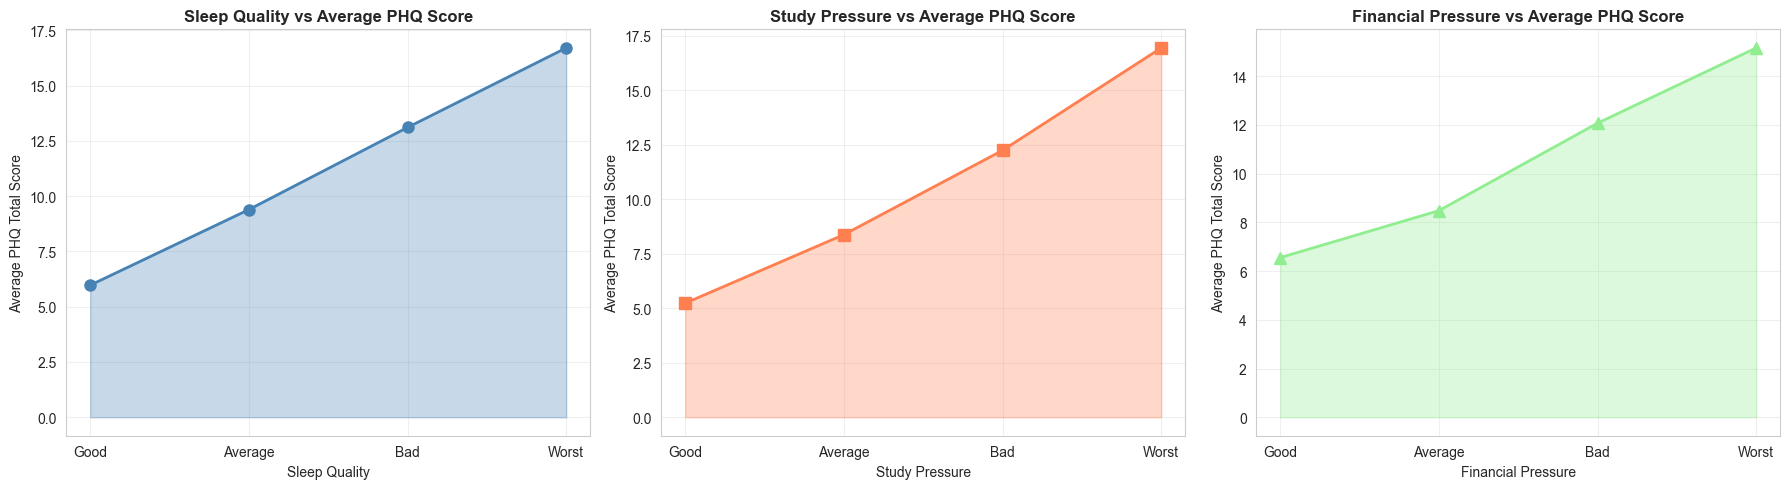

Life Pressures and Mental Health Impact Analysis Completed


In [11]:
# Analyze relationship between life pressures and mental health
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sleep Quality vs PHQ Score
sleep_phq = df_processed.groupby('Sleep Quality')['PHQ_Total'].mean()
axes[0].plot(['Good', 'Average', 'Bad', 'Worst'], sleep_phq.values, marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].fill_between(range(4), sleep_phq.values, alpha=0.3, color='steelblue')
axes[0].set_title('Sleep Quality vs Average PHQ Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average PHQ Total Score')
axes[0].set_xlabel('Sleep Quality')
axes[0].grid(True, alpha=0.3)

# Study Pressure vs PHQ Score
study_phq = df_processed.groupby('Study Pressure')['PHQ_Total'].mean()
axes[1].plot(['Good', 'Average', 'Bad', 'Worst'], study_phq.values, marker='s', linewidth=2, markersize=8, color='coral')
axes[1].fill_between(range(4), study_phq.values, alpha=0.3, color='coral')
axes[1].set_title('Study Pressure vs Average PHQ Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average PHQ Total Score')
axes[1].set_xlabel('Study Pressure')
axes[1].grid(True, alpha=0.3)

# Financial Pressure vs PHQ Score
fin_phq = df_processed.groupby('Financial Pressure')['PHQ_Total'].mean()
axes[2].plot(['Good', 'Average', 'Bad', 'Worst'], fin_phq.values, marker='^', linewidth=2, markersize=8, color='lightgreen')
axes[2].fill_between(range(4), fin_phq.values, alpha=0.3, color='lightgreen')
axes[2].set_title('Financial Pressure vs Average PHQ Score', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average PHQ Total Score')
axes[2].set_xlabel('Financial Pressure')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Life Pressures and Mental Health Impact Analysis Completed")


## Section 6: Predictive Modeling for PHQ Severity

In [12]:
# Prepare data for predictive modeling
# Features: Age, Gender, Sleep Quality, Study Pressure, Financial Pressure
feature_columns = ['Age', 'Gender', 'Sleep Quality', 'Study Pressure', 'Financial Pressure']
X = df_processed[feature_columns].copy()
y = df_processed['PHQ_Severity'].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print("Data Split for Modeling:")
print("="*80)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTarget variable (PHQ_Severity) distribution:")
print(f"Training: {pd.Series(y_train).value_counts().sort_index().to_dict()}")
print(f"Testing: {pd.Series(y_test).value_counts().sort_index().to_dict()}")


Data Split for Modeling:
Training set size: 545 samples
Testing set size: 137 samples

Target variable (PHQ_Severity) distribution:
Training: {0: 165, 1: 124, 2: 102, 3: 100, 4: 54}
Testing: {0: 41, 1: 31, 2: 26, 3: 25, 4: 14}


In [14]:
# Train Multiple Models
print("\nTraining Machine Learning Models...")
print("="*80)

# Dictionary to store models and their performance
models = {}
results = {}

# 1. Logistic Regression
print("\n1. Logistic Regression")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_lr, average='weighted', zero_division=0),
    'predictions': y_pred_lr,
    'probabilities': y_pred_proba_lr
}
models['Logistic Regression'] = lr_model

print(f"   Accuracy: {results['Logistic Regression']['accuracy']:.4f}")
print(f"   Precision: {results['Logistic Regression']['precision']:.4f}")
print(f"   Recall: {results['Logistic Regression']['recall']:.4f}")
print(f"   F1-Score: {results['Logistic Regression']['f1']:.4f}")

# 2. Random Forest
print("\n2. Random Forest")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)

results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_rf, average='weighted', zero_division=0),
    'predictions': y_pred_rf,
    'probabilities': y_pred_proba_rf
}
models['Random Forest'] = rf_model

print(f"   Accuracy: {results['Random Forest']['accuracy']:.4f}")
print(f"   Precision: {results['Random Forest']['precision']:.4f}")
print(f"   Recall: {results['Random Forest']['recall']:.4f}")
print(f"   F1-Score: {results['Random Forest']['f1']:.4f}")

# 3. Support Vector Machine
print("\n3. Support Vector Machine (SVM)")
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_pred_proba_svm = svm_model.predict_proba(X_test)

results['SVM'] = {
    'accuracy': accuracy_score(y_test, y_pred_svm),
    'precision': precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'recall': recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'f1': f1_score(y_test, y_pred_svm, average='weighted', zero_division=0),
    'predictions': y_pred_svm,
    'probabilities': y_pred_proba_svm
}
models['SVM'] = svm_model

print(f"   Accuracy: {results['SVM']['accuracy']:.4f}")
print(f"   Precision: {results['SVM']['precision']:.4f}")
print(f"   Recall: {results['SVM']['recall']:.4f}")
print(f"   F1-Score: {results['SVM']['f1']:.4f}")

print("\n" + "="*80)
print("Model Training Completed!")



Training Machine Learning Models...

1. Logistic Regression
   Accuracy: 0.4307
   Precision: 0.4200
   Recall: 0.4307
   F1-Score: 0.4031

2. Random Forest
   Accuracy: 0.4088
   Precision: 0.4038
   Recall: 0.4088
   F1-Score: 0.3986

3. Support Vector Machine (SVM)
   Accuracy: 0.4161
   Precision: 0.3997
   Recall: 0.4161
   F1-Score: 0.3654

Model Training Completed!



Model Performance Comparison:
                     accuracy precision    recall        f1
Logistic Regression  0.430657  0.419956  0.430657  0.403102
Random Forest        0.408759  0.403781  0.408759  0.398584
SVM                  0.416058  0.399656  0.416058  0.365439


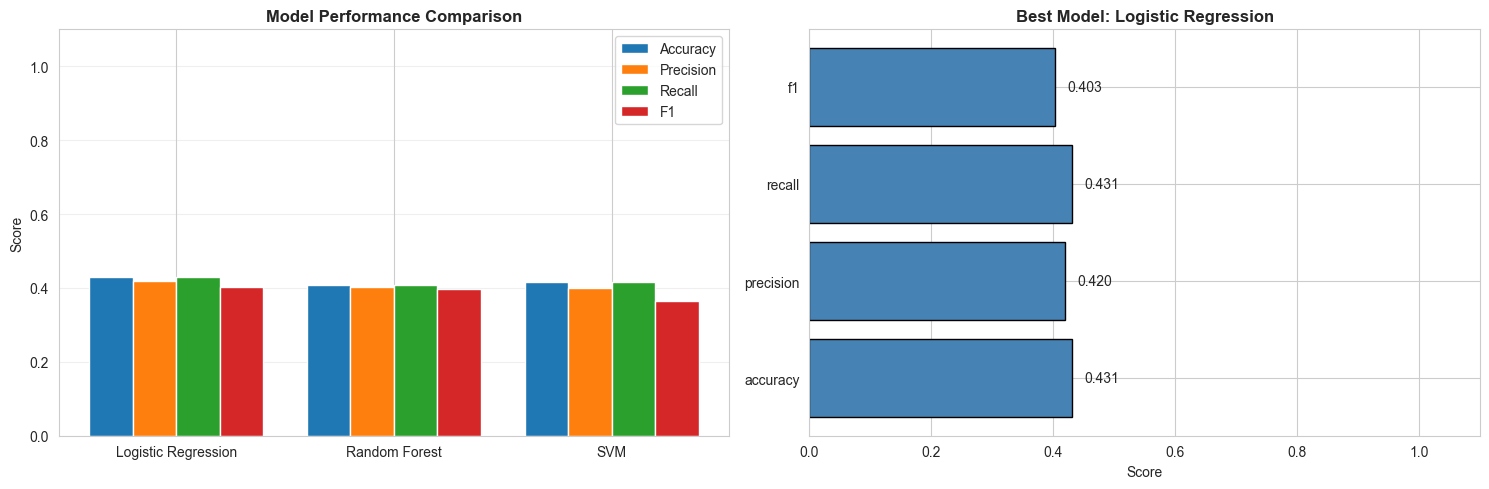


Best Model by F1-Score: Logistic Regression (F1: 0.4031)


In [15]:
# Model Performance Comparison
performance_df = pd.DataFrame(results).T
performance_df = performance_df[['accuracy', 'precision', 'recall', 'f1']]

print("\nModel Performance Comparison:")
print("="*80)
print(performance_df)

# Visualize Model Performance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot of all metrics
metrics = ['accuracy', 'precision', 'recall', 'f1']
x_pos = np.arange(len(models))
width = 0.2

for i, metric in enumerate(metrics):
    values = [results[model][metric] for model in results.keys()]
    axes[0].bar(x_pos + i*width, values, width, label=metric.capitalize())

axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos + width * 1.5)
axes[0].set_xticklabels(results.keys())
axes[0].legend()
axes[0].set_ylim([0, 1.1])
axes[0].grid(True, alpha=0.3, axis='y')

# Radar-like representation of best model (by F1-score)
best_model = performance_df['f1'].idxmax()
best_performance = performance_df.loc[best_model]
axes[1].barh(metrics, best_performance.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Score')
axes[1].set_title(f'Best Model: {best_model}', fontsize=12, fontweight='bold')
axes[1].set_xlim([0, 1.1])
for i, v in enumerate(best_performance.values):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

print(f"\nBest Model by F1-Score: {best_model} (F1: {performance_df.loc[best_model, 'f1']:.4f})")


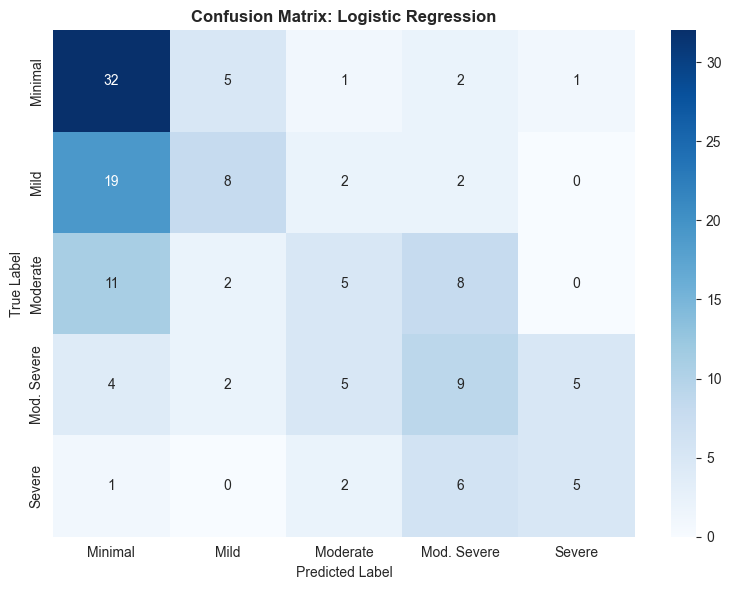


Classification Report for Logistic Regression:
                   precision    recall  f1-score   support

          Minimal       0.48      0.78      0.59        41
             Mild       0.47      0.26      0.33        31
         Moderate       0.33      0.19      0.24        26
Moderately Severe       0.33      0.36      0.35        25
           Severe       0.45      0.36      0.40        14

         accuracy                           0.43       137
        macro avg       0.41      0.39      0.38       137
     weighted avg       0.42      0.43      0.40       137



In [16]:
# Confusion Matrix for Best Model
best_model_predictions = results[best_model]['predictions']
cm = confusion_matrix(y_test, best_model_predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['Minimal', 'Mild', 'Moderate', 'Mod. Severe', 'Severe'],
            yticklabels=['Minimal', 'Mild', 'Moderate', 'Mod. Severe', 'Severe'])
ax.set_title(f'Confusion Matrix: {best_model}', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Detailed classification report
print(f"\nClassification Report for {best_model}:")
print("="*80)
print(classification_report(y_test, best_model_predictions, 
                          target_names=['Minimal', 'Mild', 'Moderate', 'Moderately Severe', 'Severe']))


## Section 7: Visualization of Key Findings and Insights

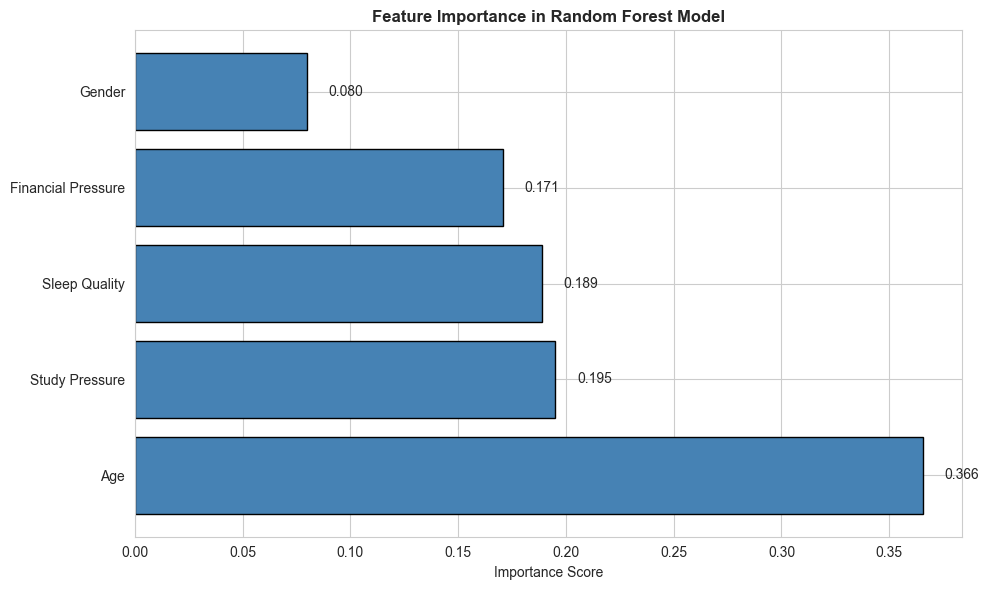

Feature Importance Scores:
              Feature  Importance
0                 Age    0.365511
3      Study Pressure    0.195087
2       Sleep Quality    0.189004
4  Financial Pressure    0.170638
1              Gender    0.079760


In [17]:
# Feature Importance Analysis (for Random Forest)
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance in Random Forest Model', fontsize=12, fontweight='bold')
for i, v in enumerate(feature_importance['Importance']):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

print("Feature Importance Scores:")
print(feature_importance)


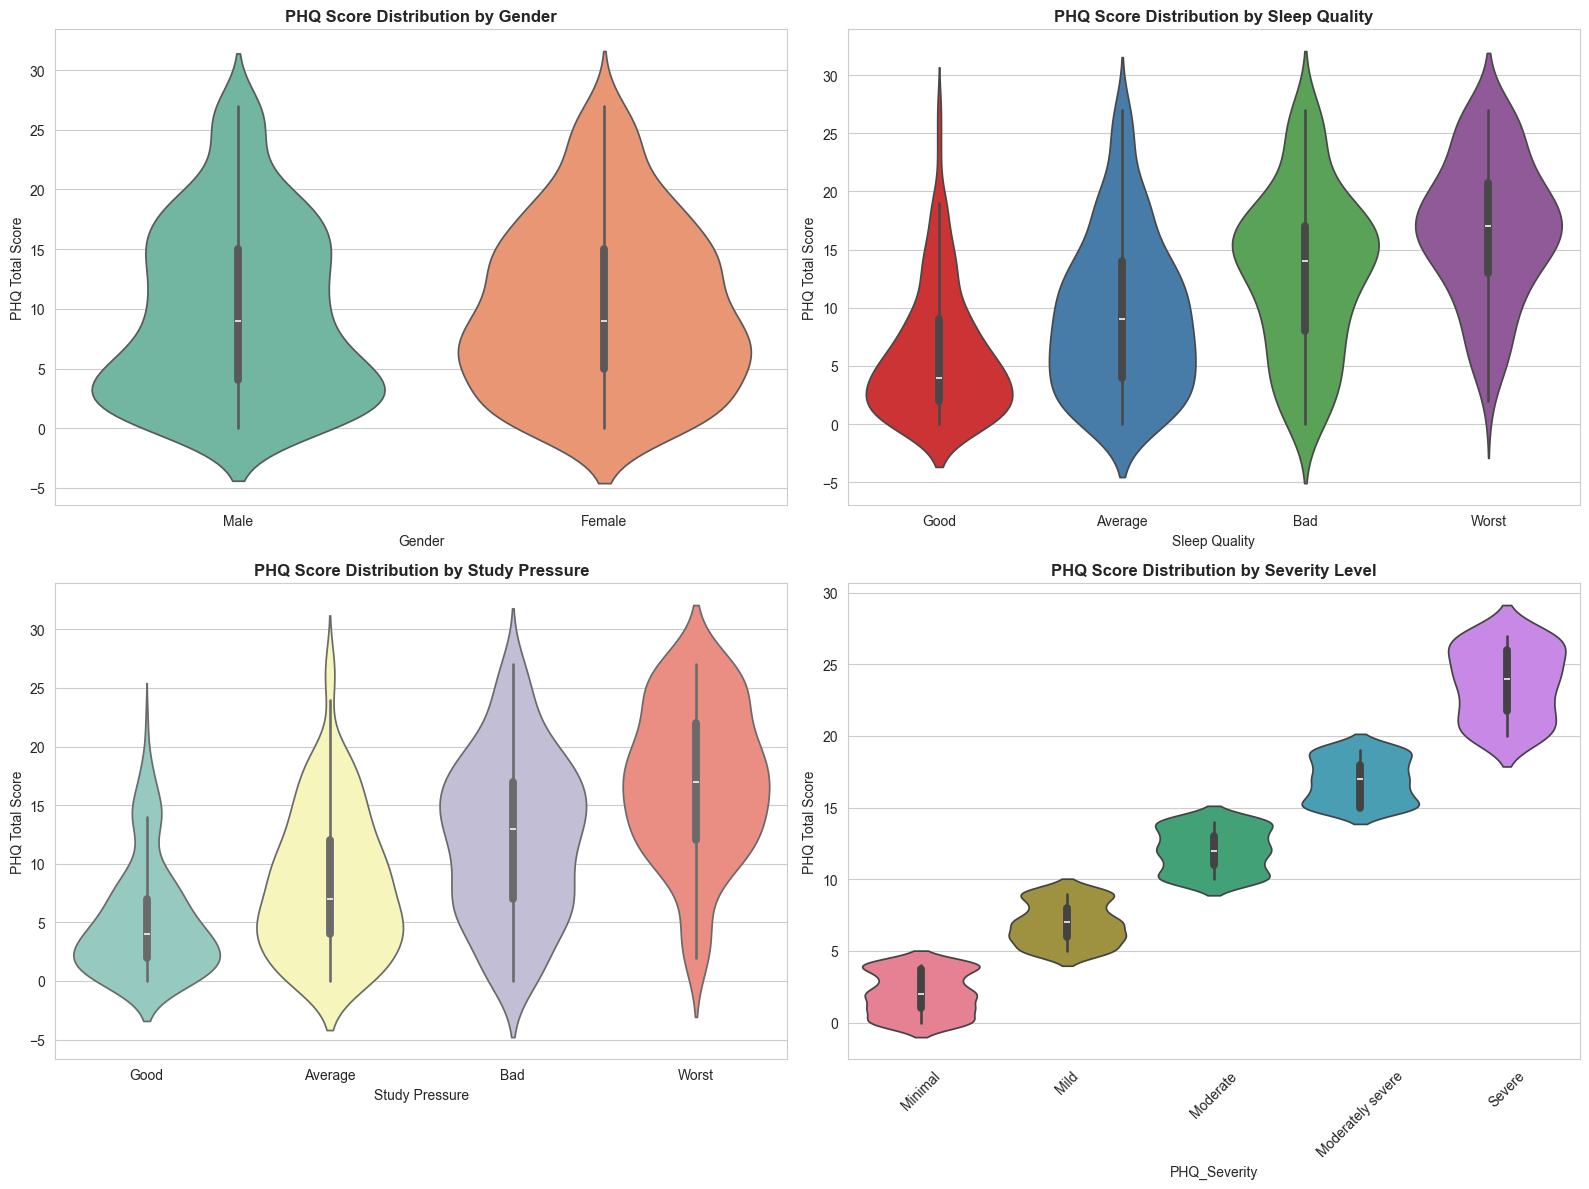

In [18]:
# Violin Plots: Distribution of PHQ Scores by Key Variables
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Create data with original labels for visualization
df_viz = df.copy()
df_viz['PHQ_Total'] = df_processed['PHQ_Total']
df_viz['Sleep_Quality_Numeric'] = df_processed['Sleep Quality']
df_viz['Study_Pressure_Numeric'] = df_processed['Study Pressure']
df_viz['Financial_Pressure_Numeric'] = df_processed['Financial Pressure']

# 1. PHQ Score by Gender
sns.violinplot(data=df_viz, x='Gender', y='PHQ_Total', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('PHQ Score Distribution by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('PHQ Total Score')

# 2. PHQ Score by Sleep Quality
sleep_order = ['Good', 'Average', 'Bad', 'Worst']
df_viz_sleep = df_viz.copy()
df_viz_sleep['Sleep Quality'] = pd.Categorical(df_viz_sleep['Sleep Quality'], categories=sleep_order, ordered=True)
sns.violinplot(data=df_viz_sleep, x='Sleep Quality', y='PHQ_Total', ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('PHQ Score Distribution by Sleep Quality', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('PHQ Total Score')

# 3. PHQ Score by Study Pressure
df_viz_study = df_viz.copy()
df_viz_study['Study Pressure'] = pd.Categorical(df_viz_study['Study Pressure'], categories=sleep_order, ordered=True)
sns.violinplot(data=df_viz_study, x='Study Pressure', y='PHQ_Total', ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('PHQ Score Distribution by Study Pressure', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('PHQ Total Score')

# 4. PHQ Score by PHQ Severity
sns.violinplot(data=df_viz, x='PHQ_Severity', y='PHQ_Total', ax=axes[1, 1], 
               order=severity_order, palette='husl')
axes[1, 1].set_title('PHQ Score Distribution by Severity Level', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('PHQ Total Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


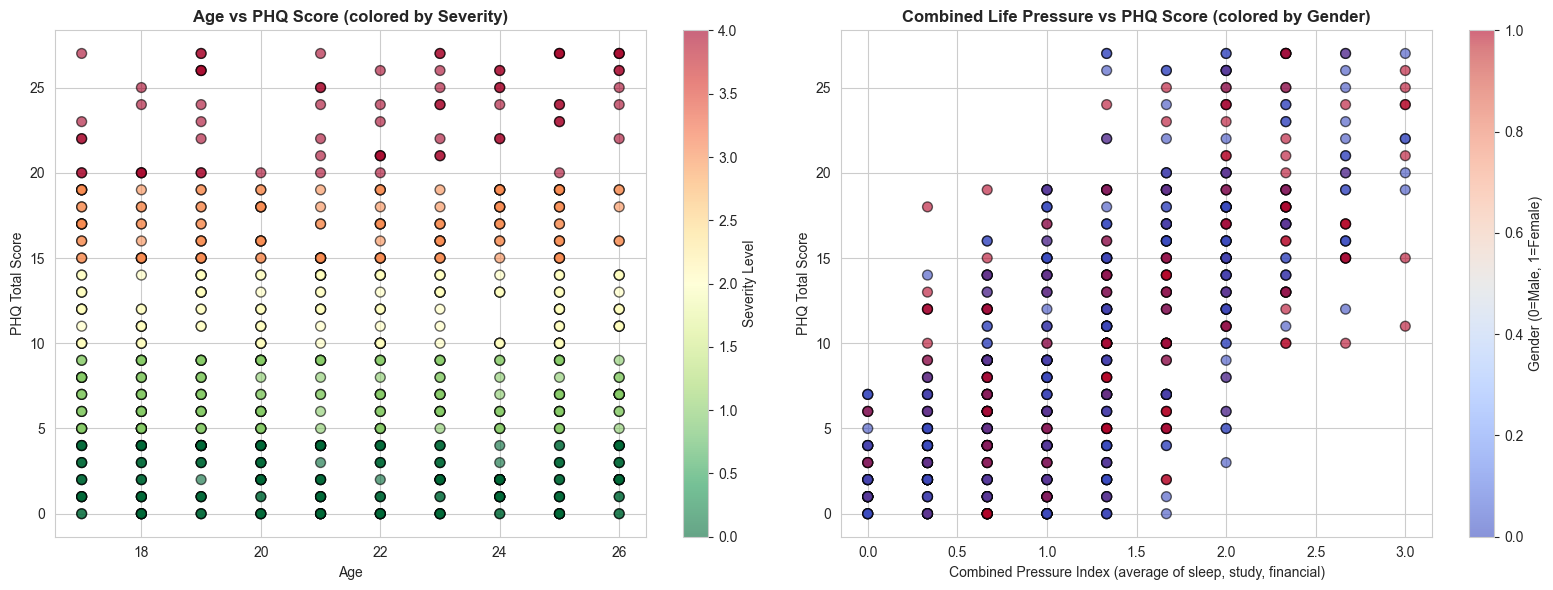

Correlation Analysis:
Age vs PHQ Total: 0.0500
Combined Pressure vs PHQ Total: 0.6889


In [19]:
# Scatter Plots: Relationships between Variables
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Age vs PHQ Score (colored by severity)
severity_colors = {0: 'green', 1: 'yellow', 2: 'orange', 3: 'red', 4: 'darkred'}
scatter_colors = df_processed['PHQ_Severity'].map(severity_colors)
scatter = axes[0].scatter(df_processed['Age'], df_processed['PHQ_Total'], 
                          c=df_processed['PHQ_Severity'], cmap='RdYlGn_r', alpha=0.6, s=50, edgecolor='black')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('PHQ Total Score')
axes[0].set_title('Age vs PHQ Score (colored by Severity)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Severity Level')

# Combined Pressure Index vs PHQ Score
df_processed['Combined_Pressure'] = (df_processed['Sleep Quality'] + 
                                      df_processed['Study Pressure'] + 
                                      df_processed['Financial Pressure']) / 3
scatter2 = axes[1].scatter(df_processed['Combined_Pressure'], df_processed['PHQ_Total'], 
                           c=df_processed['Gender'], cmap='coolwarm', alpha=0.6, s=50, edgecolor='black')
axes[1].set_xlabel('Combined Pressure Index (average of sleep, study, financial)')
axes[1].set_ylabel('PHQ Total Score')
axes[1].set_title('Combined Life Pressure vs PHQ Score (colored by Gender)', fontsize=12, fontweight='bold')
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Gender (0=Male, 1=Female)')

plt.tight_layout()
plt.show()

# Calculate correlation
print("Correlation Analysis:")
print("="*80)
print(f"Age vs PHQ Total: {df_processed[['Age', 'PHQ_Total']].corr().iloc[0, 1]:.4f}")
print(f"Combined Pressure vs PHQ Total: {df_processed[['Combined_Pressure', 'PHQ_Total']].corr().iloc[0, 1]:.4f}")


In [20]:
# Summary of Key Findings
print("\n" + "="*80)
print("SUMMARY OF KEY FINDINGS - PHQ-9 MENTAL HEALTH ANALYSIS")
print("="*80)

print("\n1. DATASET OVERVIEW:")
print(f"   - Total Students: {len(df)}")
print(f"   - Age Range: {df_processed['Age'].min()}-{df_processed['Age'].max()} years")
print(f"   - Average Age: {df_processed['Age'].mean():.1f} years")
print(f"   - Gender Split: {(df['Gender'].value_counts()['Male'])} Male, {(df['Gender'].value_counts()['Female'])} Female")

print("\n2. DEPRESSION SEVERITY FINDINGS:")
severity_dist = df['PHQ_Severity'].value_counts()
for severity in severity_order:
    count = severity_dist.get(severity, 0)
    percentage = (count / len(df)) * 100
    print(f"   - {severity}: {count} students ({percentage:.1f}%)")

print("\n3. MENTAL HEALTH STATISTICS:")
print(f"   - Average PHQ Score: {df_processed['PHQ_Total'].mean():.2f} (Range: 0-27)")
print(f"   - Median PHQ Score: {df_processed['PHQ_Total'].median():.2f}")
print(f"   - Std Deviation: {df_processed['PHQ_Total'].std():.2f}")
print(f"   - High Risk (Moderate+): {len(df[df['PHQ_Severity'].isin(['Moderate', 'Moderately severe', 'Severe'])]) / len(df) * 100:.1f}%")

print("\n4. GENDER DIFFERENCES:")
male_avg = df_processed[df_processed['Gender'] == 0]['PHQ_Total'].mean()
female_avg = df_processed[df_processed['Gender'] == 1]['PHQ_Total'].mean()
print(f"   - Male Average PHQ Score: {male_avg:.2f}")
print(f"   - Female Average PHQ Score: {female_avg:.2f}")
print(f"   - Difference: {abs(female_avg - male_avg):.2f}")

print("\n5. LIFE PRESSURES IMPACT:")
pressure_labels = ['Good', 'Average', 'Bad', 'Worst']
sleep_impact = df_processed.groupby('Sleep Quality')['PHQ_Total'].mean()
study_impact = df_processed.groupby('Study Pressure')['PHQ_Total'].mean()
fin_impact = df_processed.groupby('Financial Pressure')['PHQ_Total'].mean()
print(f"   Sleep Quality Impact: {sleep_impact.iloc[0]:.2f} (Good) → {sleep_impact.iloc[3]:.2f} (Worst)")
print(f"   Study Pressure Impact: {study_impact.iloc[0]:.2f} (Good) → {study_impact.iloc[3]:.2f} (Worst)")
print(f"   Financial Pressure Impact: {fin_impact.iloc[0]:.2f} (Good) → {fin_impact.iloc[3]:.2f} (Worst)")

print("\n6. MOST CONCERNING SYMPTOMS (Highest Correlation with Total Score):")
top_symptoms = symptom_correlations.head(3)
for i, (symptom, corr) in enumerate(top_symptoms.items(), 1):
    print(f"   {i}. {symptom}: {corr:.4f}")

print("\n7. PREDICTIVE MODELING RESULTS:")
print(f"   - Best Model: {best_model}")
print(f"   - Accuracy: {results[best_model]['accuracy']:.4f}")
print(f"   - F1-Score: {results[best_model]['f1']:.4f}")
print(f"   - Most Important Feature: {feature_importance.iloc[0]['Feature']}")

print("\n8. RECOMMENDATIONS:")
print("   ✓ Sleep quality is a major contributor to mental health")
print("   ✓ Academic and financial pressures significantly impact depression levels")
print("   ✓ Females show slightly higher depression scores than males")
print("   ✓ Early intervention important for students with multiple pressure factors")

print("\n" + "="*80)



SUMMARY OF KEY FINDINGS - PHQ-9 MENTAL HEALTH ANALYSIS

1. DATASET OVERVIEW:
   - Total Students: 682
   - Age Range: 17-26 years
   - Average Age: 21.4 years
   - Gender Split: 418 Male, 264 Female

2. DEPRESSION SEVERITY FINDINGS:
   - Minimal: 206 students (30.2%)
   - Mild: 155 students (22.7%)
   - Moderate: 128 students (18.8%)
   - Moderately severe: 125 students (18.3%)
   - Severe: 68 students (10.0%)

3. MENTAL HEALTH STATISTICS:
   - Average PHQ Score: 9.90 (Range: 0-27)
   - Median PHQ Score: 9.00
   - Std Deviation: 7.22
   - High Risk (Moderate+): 47.1%

4. GENDER DIFFERENCES:
   - Male Average PHQ Score: 9.75
   - Female Average PHQ Score: 10.15
   - Difference: 0.40

5. LIFE PRESSURES IMPACT:
   Sleep Quality Impact: 5.97 (Good) → 16.71 (Worst)
   Study Pressure Impact: 5.23 (Good) → 16.93 (Worst)
   Financial Pressure Impact: 6.55 (Good) → 15.16 (Worst)

6. MOST CONCERNING SYMPTOMS (Highest Correlation with Total Score):
   1.   Feeling tired or having little energy  